MAE
MSE
RMSE
R2



Classification:
1) Accuracy
2) Precision
3) Recall
4) F1 Score - confusion matrix

BREAST CANCER DETECTION - MINI PROJECT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
# classification evaluation metrics are needed here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
load_breast_cancer().data.shape

(569, 30)

In [3]:
# Feature Selection - already done by sklearn
X = load_breast_cancer().data

y = load_breast_cancer().target
# malignant or Benign
# Cancer - moving around cancer cell === Benign means local and dead

In [4]:
column_names = load_breast_cancer().feature_names

In [5]:
df = pd.DataFrame(X, columns = column_names)

df['target'] = y

# df.head()

df.sample(5)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
422,11.61,16.02,75.46,408.2,0.10880,0.11680,0.070970,0.044970,0.1886,0.06320,...,19.67,81.93,475.7,0.1415,0.21700,0.230200,0.11050,0.2787,0.07427,1
409,12.27,17.92,78.41,466.1,0.08685,0.06526,0.032110,0.026530,0.1966,0.05597,...,28.88,89.00,610.2,0.1240,0.17950,0.137700,0.09532,0.3455,0.06896,1
58,13.05,19.31,82.61,527.2,0.08060,0.03789,0.000692,0.004167,0.1819,0.05501,...,22.25,90.24,624.1,0.1021,0.06191,0.001845,0.01111,0.2439,0.06289,1
259,15.53,33.56,103.70,744.9,0.10630,0.16390,0.175100,0.083990,0.2091,0.06650,...,49.54,126.30,1035.0,0.1883,0.55640,0.570300,0.20140,0.3512,0.12040,0
514,15.05,19.07,97.26,701.9,0.09215,0.08597,0.074860,0.043350,0.1561,0.05915,...,28.06,113.80,967.0,0.1246,0.21010,0.286600,0.11200,0.2282,0.06954,0


In [6]:
# train test split - 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y # homework for today
                                                    )

print(f"Train size => {X_train.shape}")
print(f"Target for Train, size => {y_train.shape}")

print(f"Test size => {X_test.shape}")
print(f"Target for Test, size => {y_test.shape}")

Train size => (455, 30)
Target for Train, size => (455,)
Test size => (114, 30)
Target for Test, size => (114,)


In [7]:
# modelling step - we choose our model 
# we can adjust some knobs in these models
# these are called Model Hyperparameters

model_tree = DecisionTreeClassifier(
    max_depth = 3, # depth is small
    criterion= 'gini', # gini entropy or log-loss
    random_state = 42
)

# train the model
model_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [8]:
# make predictions

y_pred_test = model_tree.predict(X_test) # unseen data
y_pred_train = model_tree.predict(X_train) # model has seeen these inputs

# Evaluation of the model
test_acc = accuracy_score(y_test, y_pred_test) # Testing accuracy
train_acc = accuracy_score(y_train, y_pred_train) #  Training accuracy

print("====== Model Evaluation ======")
print(f"Testing Accuracy: {test_acc*100:.2f}%")
print(f"Training Accuracy: {train_acc*100:.2f}%")


====== Model Evaluation ======
Testing Accuracy: 94.74%
Training Accuracy: 97.80%


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("---------------Confusion Matrix--------------\n",cm)

---------------Confusion Matrix--------------
 [[39  4]
 [ 2 69]]


In [10]:
# Classification Report
cr = classification_report(y_test, y_pred_test)
print("---------------Classification Report--------------\n",cr)

---------------Classification Report--------------
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



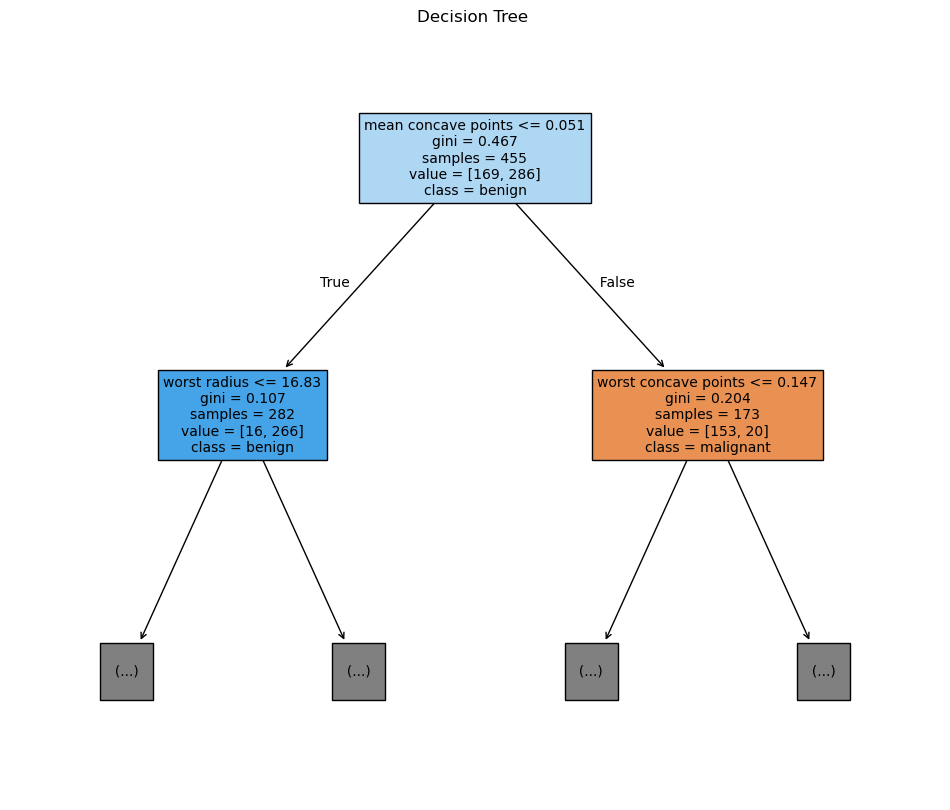

In [11]:
## Visualizing Decision Tree

plt.figure(figsize = (12, 10))

plot_tree(model_tree,
          feature_names= load_breast_cancer().feature_names,
          class_names= load_breast_cancer().target_names,
          filled= True,
          max_depth= 1
          )

plt.title("Decision Tree ")
plt.show()

In [12]:
importances = model_tree.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending= False).head(7)
df_top_features

,features,importance
7,mean concave points,0.752304
27,worst concave points,0.071432
20,worst radius,0.056905
22,worst perimeter,0.056028
1,mean texture,0.030106
19,fractal dimension error,0.020188
13,area error,0.013038


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'mean concave points'),
  Text(1, 0, 'worst concave points'),
  Text(2, 0, 'worst radius'),
  Text(3, 0, 'worst perimeter'),
  Text(4, 0, 'mean texture'),
  Text(5, 0, 'fractal dimension error'),
  Text(6, 0, 'area error')])

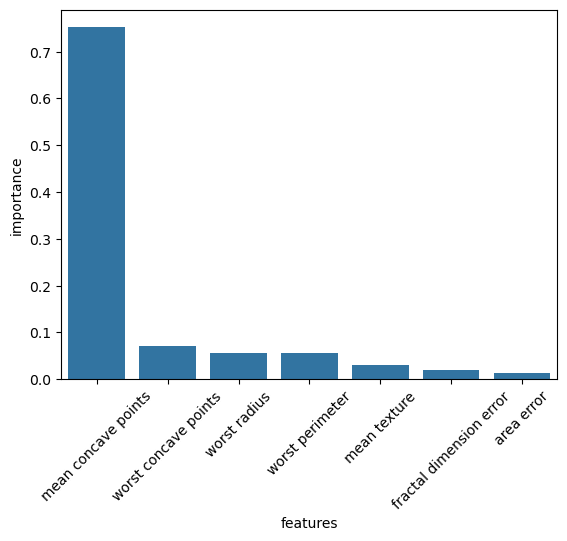

In [13]:
sns.barplot(df_top_features, x= 'features', y = 'importance')

plt.xticks(rotation = 45)

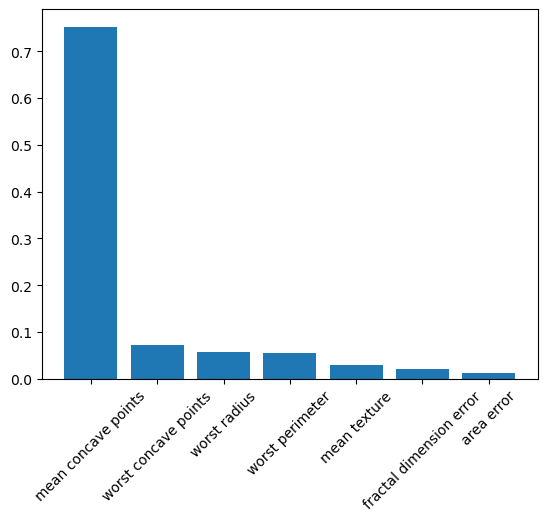

In [14]:
plt.bar(df_top_features['features'], df_top_features['importance'])

plt.xticks(rotation = 45)
plt.show()

In [15]:
importances = model_tree.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending= False).head(7)
df_top_features

,features,importance
7,mean concave points,0.752304
27,worst concave points,0.071432
20,worst radius,0.056905
22,worst perimeter,0.056028
1,mean texture,0.030106
19,fractal dimension error,0.020188
13,area error,0.013038


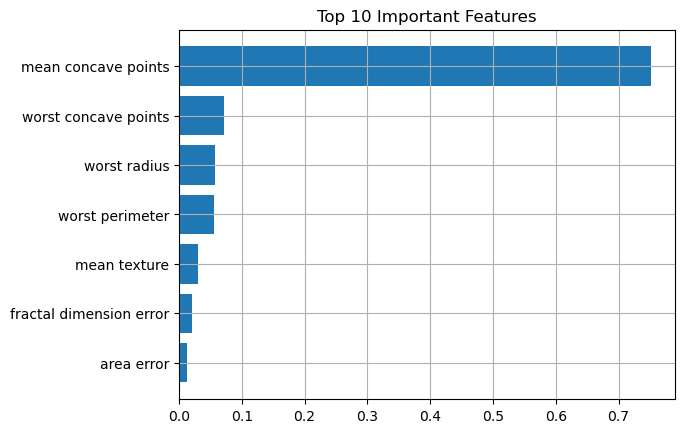

In [16]:
plt.barh(df_top_features['features'], df_top_features['importance'])
plt.gca().invert_yaxis() # invert the axis --- largest on TOP

plt.title("Top 10 Important Features")
plt.grid()
plt.show()

In [1]:
importances = model_rf_clf.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending = False)
top_features = df_top_features.head(15)['features'].reset_index(drop = True)
top_features

NameError: name 'model_rf_clf' is not defined

In [2]:
# Random Forest Classifier
model_rf_clf = RandomForestClassifier(
    n_estimators = 10,
    random_state= 42
)

model_rf_clf.fit(X_train, y_train)

NameError: name 'RandomForestClassifier' is not defined